In [1]:
import pandas as pd
import zipfile
import io
import sys, os
from pathlib import Path
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from tqdm import tqdm
project_root = "/home/shuol/ls_learnqf"
if project_root not in sys.path:
    sys.path.append(project_root)
from util import *
from stock_pool import *
import tushare as ts
import time
import pickle

In [2]:
panel_df = pd.read_pickle("panel_df.pkl")

经验证据表明，低波动股票收益表现往往优于高波动股票，股票收益与波动之间存在着负相关性。为了检验A股市场的低波动异象，选取振幅因子作为波动类因子的代理变量。\
为了进一步分析振幅因子的信息结构，引入价格维度。预期在不同价格位置，振幅分布所蕴含的信息会存在结构性差异。

回测区间为2010年4月30日至2020年4月30日；样本空间为全体A股，剔除ST股和上市未满60 日的新股；每月月初调仓，持仓一个自然月，交易费率千分之三。

In [2]:
# 初始化pro接口
pro = ts.pro_api()

# 获取回测区间的样本空间 
universe_df = get_history_sample_space_df(pro=pro,start_date='20100430', end_date='20200430', pool_type='ALL', 
                                          include_bj=False, min_list_days=60, freq='M', sleep_interval=0.1)

#获取股票池的历史日行情数据
price_df = get_daily_price_for_universe(pro=pro, universe_df=universe_df,start_date='20100301', end_date='20200430',
                                        fields='ts_code,trade_date,open,high,low,close,pre_close,vol,amount')

#整理df
price_df['trade_date'] = pd.to_datetime(price_df['trade_date'])
panel_df = price_df.sort_values(['ts_code', 'trade_date']).reset_index(drop=True)

下载区间日频行情:  35%|████████████████████▌                                      | 1247/3570 [23:55<2:48:15,  4.35s/it]

请求 002241.SZ 数据时发生错误: HTTPConnectionPool(host='api.waditu.com', port=80): Read timed out. (read timeout=30)


下载区间日频行情:  87%|█████████████████████████████████████████████████████▏       | 3110/3570 [55:52<09:18,  1.21s/it]

请求 300690.SZ 数据时发生错误: HTTPConnectionPool(host='api.waditu.com', port=80): Read timed out.


下载区间日频行情: 100%|███████████████████████████████████████████████████████████| 3570/3570 [1:01:39<00:00,  1.04s/it]


In [3]:
panel_df

,ts_code,trade_date,open,high,low,close,pre_close,vol,amount
0,000001.SZ,2010-03-02,22.89,23.96,22.89,23.11,22.45,684647.27,1.599220e+06
1,000001.SZ,2010-03-03,23.11,23.35,22.80,23.30,23.11,284111.39,6.554447e+05
2,000001.SZ,2010-03-04,23.32,23.63,23.00,23.10,23.30,376320.84,8.773898e+05
3,000001.SZ,2010-03-05,23.10,23.49,23.05,23.27,23.10,291842.10,6.811939e+05
4,000001.SZ,2010-03-08,23.32,24.05,23.06,23.85,23.27,441053.92,1.045699e+06
...,...,...,...,...,...,...,...,...,...
6078139,688399.SH,2020-04-24,150.00,153.00,138.08,144.08,128.88,46408.37,6.756643e+05
6078140,688399.SH,2020-04-27,135.00,140.00,126.00,126.20,144.08,35730.24,4.691092e+05
6078141,688399.SH,2020-04-28,123.20,134.99,121.76,127.60,126.20,26022.02,3.358797e+05
6078142,688399.SH,2020-04-29,128.83,131.00,117.78,118.00,127.60,27430.22,3.349412e+05


**振幅因子** ：回看最近20个交易日，计算股票每日的振幅（最高价/最低价-1），取其均值作为振幅因子。\
\
价格维度下的振幅因子切割方案：
1. 数据回溯  
   对选定股票 $ S $，回溯获取其最近 $N$ 个交易日的数据（研报里 $N = 20$）。
2. 振幅计算
   计算股票 $ S $每日的振幅：
   $
   \text{振幅} = \frac{\text{最高价}}{\text{最低价}} - 1
   $
3. 高价振幅因子 $V_{\text{high}}(\lambda)$
   选择收盘价较高的前 $\lambda $（例如 40%）的有效交易日，计算这些交易日振幅的均值，得到高价振幅因子：
   $
   V_{\text{high}}(\lambda)
   $
4. 低价振幅因子 $ V_{\text{low}}(\lambda) $
   选择收盘价较低的前 $\lambda $（例如 40%）的有效交易日，计算这些交易日振幅的均值，得到低价振幅因子：
   $
   V_{\text{low}}(\lambda)
   $

In [4]:
def calculate_amplitude_factors(daily_data: pd.DataFrame,N: int = 20,lambda_ratio: float = 0.4,ticker_col: str = 'ticker',
                                date_col: str = 'date') -> pd.DataFrame:
    """
    计算价格维度下的振幅因子 V_high, V_low

    """
    df = daily_data.sort_values([ticker_col, date_col]).copy()

    # 基础字段
    df['amp'] = df['high'] / df['low'] - 1.0

    # 有效交易日过滤
    # 停牌/无成交：vol<=0 或 amount<=0 或价格缺失
    valid_trade = (df['close'].notna() & df['high'].notna() & df['low'].notna() & (df['low'] > 0))

    if 'vol' in df.columns:
        valid_trade &= (df['vol'].fillna(0) > 0)
    if 'amount' in df.columns:
        valid_trade &= (df['amount'].fillna(0) > 0)

    # 剔除一字涨跌停：high == low
    one_word_board = np.isclose(df['high'], df['low'], equal_nan=False)

    df['is_valid_day'] = valid_trade & (~one_word_board)

    def rolling_slice(group):
        close = group['close'].to_numpy()
        amp = group['amp'].to_numpy()
        is_valid = group['is_valid_day'].to_numpy()
        n = len(group)

        v_high = np.full(n, np.nan)
        v_low = np.full(n, np.nan)

        if n < N:
            return pd.DataFrame({'V_high': v_high, 'V_low': v_low}, index=group.index)

        for i in range(N - 1, n):
            window_close = close[i - N + 1: i + 1]
            window_amp = amp[i - N + 1: i + 1]
            window_valid = is_valid[i - N + 1: i + 1]

            # 仅保留有效交易日
            w_c = window_close[window_valid]
            w_a = window_amp[window_valid]

            # 报告：有效交易日少于10日则置空
            if len(w_c) < 10:
                continue

            # 取 lambda 比例的有效交易日
            k = int(len(w_c) * lambda_ratio)
            k = max(1, k)

            sort_idx = np.argsort(w_c)

            # 低价区振幅均值
            v_low[i] = np.mean(w_a[sort_idx[:k]])
            # 高价区振幅均值
            v_high[i] = np.mean(w_a[sort_idx[-k:]])

        return pd.DataFrame({'V_high': v_high, 'V_low': v_low}, index=group.index)

    res = df.groupby(ticker_col, group_keys=False).apply(rolling_slice)
    df['V_high'] = res['V_high']
    df['V_low'] = res['V_low']

    return df

In [5]:
#月收益
df_clean = panel_df.copy()
df_clean['trade_date'] = pd.to_datetime(df_clean['trade_date'])
df_clean = df_clean.sort_values(['ts_code', 'trade_date']).copy()

# 月份标签
df_clean['year_month'] = df_clean['trade_date'].dt.to_period('M')

# 每月第一个/最后一个交易日
df_monthly_first = df_clean.groupby(['ts_code', 'year_month']).first().reset_index()
df_monthly_last = df_clean.groupby(['ts_code', 'year_month']).last().reset_index()

# 月收益：月初收盘买入，月末收盘卖出
df_monthly_return = pd.merge(
    df_monthly_first[['ts_code', 'year_month', 'close']],
    df_monthly_last[['ts_code', 'year_month', 'close']],
    on=['ts_code', 'year_month'],
    suffixes=('_start', '_end'))

df_monthly_return['monthly_return'] = (df_monthly_return['close_end'] / df_monthly_return['close_start'] - 1)

In [6]:
#主流程
lambda_list = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

results_v_high = {}
results_v_low = {}
merged_data_dict = {}

# 因子计算时统一字段名
df_for_factor = df_clean.rename(columns={'ts_code': 'ticker', 'trade_date': 'date'}).copy()

for lam in tqdm(lambda_list, desc="计算不同 Lambda 因子表现"):
    
    # 日频振幅因子
    df_factor_raw = calculate_amplitude_factors(daily_data=df_for_factor, N=20, lambda_ratio=lam, ticker_col='ticker',
                                                date_col='date').rename(columns={'ticker': 'ts_code', 'date': 'trade_date'})

    # 取每个月最后一个交易日的因子值
    df_factor_raw['year_month'] = df_factor_raw['trade_date'].dt.to_period('M')
    #df_factor_monthly = df_factor_raw.groupby(['ts_code', 'year_month']).last().reset_index()
    df_factor_monthly = (df_factor_raw.sort_values(['ts_code', 'trade_date']).groupby(['ts_code', 'year_month']).tail(1).reset_index(drop=True))

    # 上个月末信号 -> 下个月收益
    df_factor_monthly['signal_month'] = df_factor_monthly['year_month'] + 1

    temp_df = pd.merge(df_monthly_return[['ts_code', 'year_month', 'monthly_return']],
                       df_factor_monthly[['ts_code', 'signal_month', 'V_high', 'V_low']],left_on=['ts_code', 'year_month'],
                       right_on=['ts_code', 'signal_month'],how='inner')

    merged_data_dict[lam] = temp_df.copy()

    # 回测 V_high
    res_high = run_factor_backtest(panel_df=temp_df, factor_col='V_high', ret_col='monthly_return', date_col='year_month', 
                                   freq='M',q=5, fee_rate=0.003, factor_order='ascending')

    # 回测 V_low
    res_low = run_factor_backtest(panel_df=temp_df, factor_col='V_low', ret_col='monthly_return', date_col='year_month', 
                                  freq='M',q=5, fee_rate=0.003, factor_order='ascending')

    results_v_high[lam] = res_high
    results_v_low[lam] = res_low

计算不同 Lambda 因子表现: 100%|██████████████████████████████████████████████████████████| 9/9 [15:30<00:00, 103.38s/it]


因子绩效指标可视化

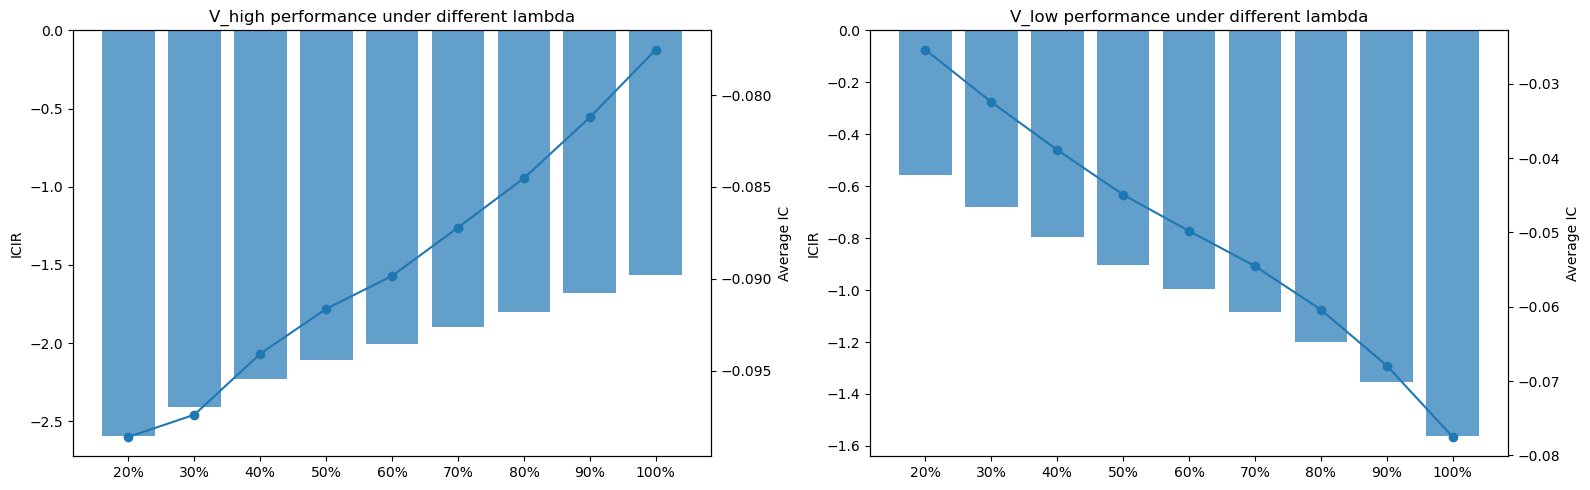

In [7]:
lambdas_str = [f'{int(l * 100)}%' for l in lambda_list]

#高低对比
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax1 = axes[0]
ax1.bar(lambdas_str, [results_v_high[l]['ic_summary']['ICIR'] for l in lambda_list], alpha=0.7)
ax1.set_ylabel('ICIR')
ax1.set_title('V_high performance under different lambda')

ax1_t = ax1.twinx()
ax1_t.plot(lambdas_str, [results_v_high[l]['ic_summary']['IC均值'] for l in lambda_list], marker='o')
ax1_t.set_ylabel('Average IC')

ax2 = axes[1]
ax2.bar(lambdas_str, [results_v_low[l]['ic_summary']['ICIR'] for l in lambda_list], alpha=0.7)
ax2.set_ylabel('ICIR')
ax2.set_title('V_low performance under different lambda')

ax2_t = ax2.twinx()
ax2_t.plot(lambdas_str, [results_v_low[l]['ic_summary']['IC均值'] for l in lambda_list], marker='o')
ax2_t.set_ylabel('Average IC')

plt.tight_layout()
plt.show()

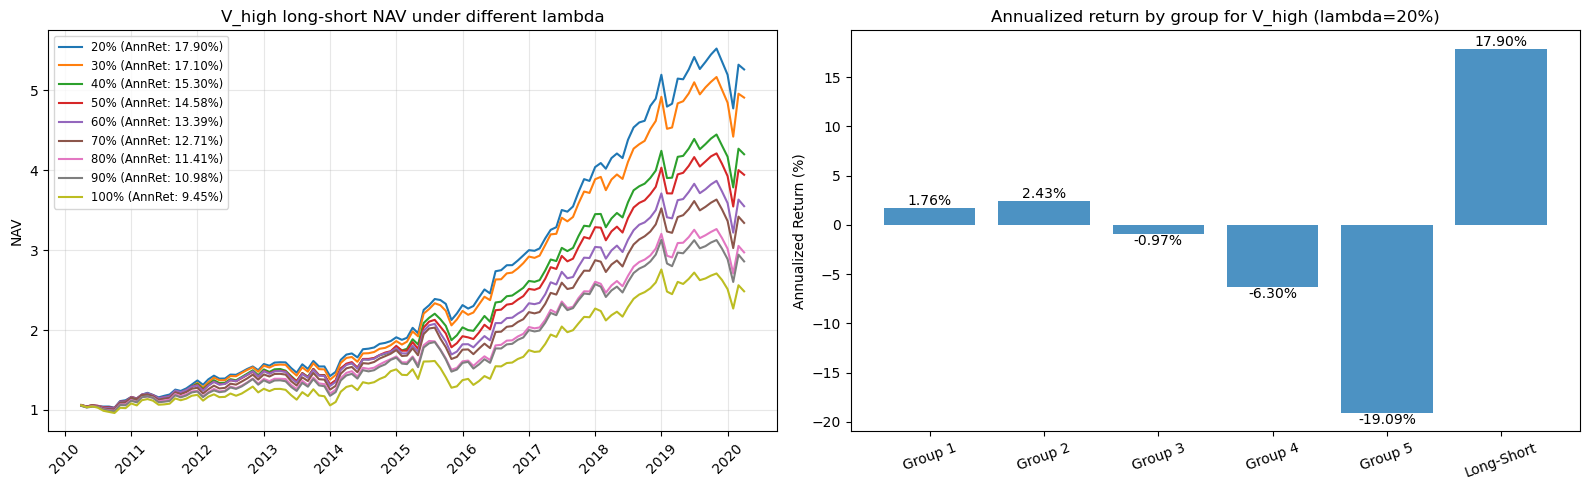

In [8]:
# Long-short NAV and annualized returns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#  V_high long-short NAV under different lambda 
ax3 = axes[0]
for lam in lambda_list:
    ls_ret = results_v_high[lam]['group_ret']['Long_Short']
    nav = results_v_high[lam]['long_short_nav'].copy()
    metric = get_metrics(ls_ret, freq='M')
    ann_ret = metric['年化收益率']

    x = nav.index.to_timestamp() if hasattr(nav.index, 'to_timestamp') else nav.index
    ax3.plot(x, nav.values, label=f'{int(lam * 100)}% (AnnRet: {ann_ret})')

ax3.set_title('V_high long-short NAV under different lambda')
ax3.set_ylabel('NAV')
ax3.legend(loc='upper left', fontsize='small')
ax3.grid(alpha=0.3)

ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax3.get_xticklabels(), rotation=45)

# Annualized return by group when lambda=20% 
ax4 = axes[1]
target_lam = 0.2
group_ret_20 = results_v_high[target_lam]['group_ret']

plot_cols = [f'Group_{i}' for i in range(5)] + ['Long_Short']
labels = ['Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Long-Short']

ann_rets = []
for col in plot_cols:
    metric = get_metrics(group_ret_20[col], freq='M')
    ann_rets.append(float(metric['年化收益率'].replace('%', '')))

bars = ax4.bar(labels, ann_rets, alpha=0.8)
ax4.set_title( 'Annualized return by group for V_high (lambda=20%)')
ax4.set_ylabel('Annualized Return (%)')
ax4.tick_params(axis='x', rotation=20)

for b in bars:
    h = b.get_height()
    va = 'bottom' if h >= 0 else 'top'
    ax4.text(b.get_x() + b.get_width() / 2,h,f'{h:.2f}%',ha='center',va=va)

plt.tight_layout()
plt.show()

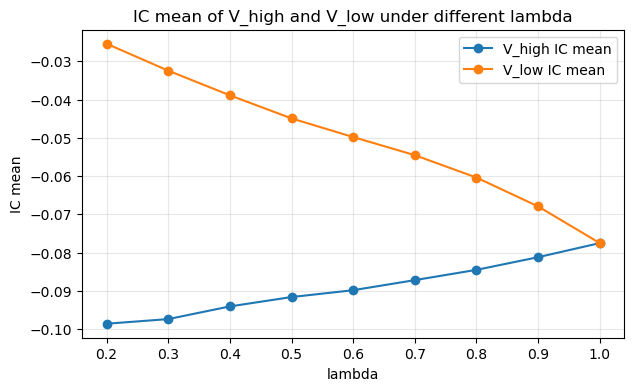

In [9]:
#不同lambda下V_high和V_low平均IC对比
compare_list = []

for lam in lambda_list:
    ic_high = results_v_high[lam]['ic_summary'].get('IC均值', np.nan)
    ic_low = results_v_low[lam]['ic_summary'].get('IC均值', np.nan)
    
    compare_list.append({'lambda': lam, 'V_high_IC均值': ic_high, 'V_low_IC均值': ic_low})

compare_df = pd.DataFrame(compare_list)

plt.figure(figsize=(7, 4))
plt.plot(compare_df['lambda'], compare_df['V_high_IC均值'], marker='o', label='V_high IC mean')
plt.plot(compare_df['lambda'], compare_df['V_low_IC均值'], marker='o', label='V_low IC mean')
plt.xlabel('lambda')
plt.ylabel('IC mean')
plt.title('IC mean of V_high and V_low under different lambda')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

具体数值和研报有差异，但是整体趋势相同：$\lambda$ 越小，$V_{high}$ 更强、$V_{low}$ 更弱。

高价振幅因子具有更强的负向选股能力, 但年化波动率和最大回撤也相对较高。\
为了提升高价振幅因子$V_{\text{high}}$ 的选股稳定性，考虑在横截面上对高价振幅因子进行标准化处理。\
这里标准化的做法是：在同一切割比例$\lambda$下，我们将高价振幅
因子$V_{\text{high}}$ 与低价振幅因子$V_{\text{low}}$ 作差，构造得到**理想振幅因子$V$**，表达式如下：
$$V(\lambda) = V_{\text{high}}(\lambda) - V_{\text{low}}(\lambda)$$

因子构造和回测

In [58]:
lambda_list_ideal = [0.2, 0.3, 0.4, 0.5]
results_v_ideal = {}

for lam in lambda_list_ideal:
    temp_df = merged_data_dict[lam].copy()
    
    # 理想振幅因子
    temp_df['V'] = temp_df['V_high'] - temp_df['V_low']
    
    # 以防后面还要反复用，存回去
    merged_data_dict[lam] = temp_df

    # 只回测新因子 V
    res_ideal = run_factor_backtest(panel_df=temp_df,factor_col='V',ret_col='monthly_return', date_col='year_month',
                                    freq='M',q=5,fee_rate=0.003,factor_order='ascending')
    
    results_v_ideal[lam] = res_ideal
    
ideal_summary_list = []

for lam in lambda_list_ideal:
    ic_mean = results_v_ideal[lam]['ic_summary'].get('IC均值', np.nan)
    icir = results_v_ideal[lam]['ic_summary'].get('ICIR', np.nan)
    perf = results_v_ideal[lam]['performance']

    ideal_summary_list.append({'lambda': lam, 'IC均值': ic_mean,'ICIR': icir, '年化收益率': perf.get('年化收益率', np.nan),
                               '年化波动率': perf.get('年化波动率', np.nan),'最大回撤': perf.get('最大回撤', np.nan),
                               '夏普比率': perf.get('夏普比率', np.nan)})

ideal_summary_df = pd.DataFrame(ideal_summary_list)

理想振幅因子回测可视化

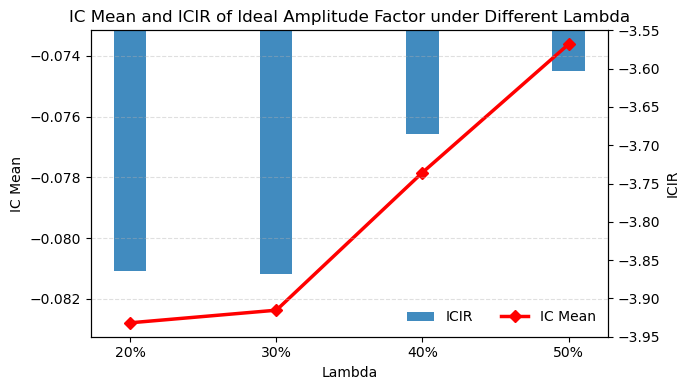

In [11]:
ideal_summary_df = ideal_summary_df.sort_values('lambda').reset_index(drop=True)

x = np.arange(len(ideal_summary_df))
xlabels = [f'{int(lam * 100)}%' for lam in ideal_summary_df['lambda']]

ic_mean = ideal_summary_df['IC均值'].values
icir = ideal_summary_df['ICIR'].values

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

#ICIR柱状图
bars = ax2.bar(x,icir,width=0.22,alpha=0.85,label='ICIR',zorder=2)
ax2.set_ylabel('ICIR')

# tighten right axis
y2_min = np.floor((icir.min() - 0.05) * 20) / 20
y2_max = np.ceil((icir.max() + 0.05) * 20) / 20
ax2.set_ylim(y2_min, y2_max)

#IC折线
line = ax1.plot(x,ic_mean,marker='D',color = "red", linewidth=2.5,label='IC Mean',zorder=1)
ax1.set_xlabel('Lambda')
ax1.set_ylabel('IC Mean')
ax1.set_xticks(x)
ax1.set_xticklabels(xlabels)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# make line axis stay above bar axis
ax1.set_zorder(2)
ax2.set_zorder(1)
ax1.patch.set_visible(False)

# legend above everything
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
legend = ax1.legend(lines2 + lines1,labels2 + labels1,loc='lower right',ncol=2,frameon=False)
legend.set_zorder(10)

ax1.set_title('IC Mean and ICIR of Ideal Amplitude Factor under Different Lambda')

plt.tight_layout()
plt.show()

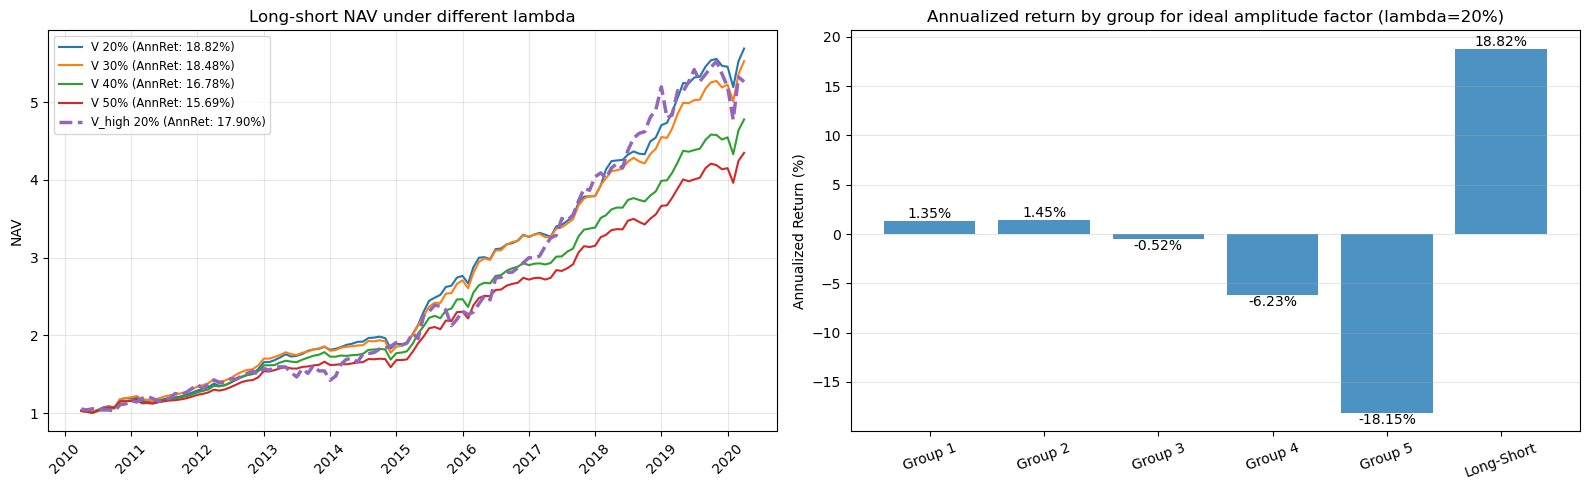

In [12]:
# Long-short NAV and annualized returns for ideal amplitude factor
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#  V long-short NAV under different lambda
ax3 = axes[0]
for lam in lambda_list_ideal:
    ls_ret = results_v_ideal[lam]['group_ret']['Long_Short']
    nav = results_v_ideal[lam]['long_short_nav'].copy()
    metric = get_metrics(ls_ret, freq='M')
    ann_ret = metric['年化收益率']

    x = nav.index.to_timestamp() if hasattr(nav.index, 'to_timestamp') else nav.index
    ax3.plot(x, nav.values, label=f'V {int(lam * 100)}% (AnnRet: {ann_ret})')

lam_high = 0.2
ls_ret_high = results_v_high[lam_high]['group_ret']['Long_Short']
nav_high = results_v_high[lam_high]['long_short_nav'].copy()
metric_high = get_metrics(ls_ret_high, freq='M')
ann_ret_high = metric_high['年化收益率']

x_high = nav_high.index.to_timestamp() if hasattr(nav_high.index, 'to_timestamp') else nav_high.index
ax3.plot(x_high,nav_high.values,linewidth=2.5,linestyle='--',label=f'V_high 20% (AnnRet: {ann_ret_high})')

ax3.set_title('Long-short NAV under different lambda')
ax3.set_ylabel('NAV')
ax3.legend(loc='upper left', fontsize='small')
ax3.grid(alpha=0.3)

ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax3.get_xticklabels(), rotation=45)

#Annualized return by group for one lambda
ax4 = axes[1]
target_lam = 0.2
group_ret_target = results_v_ideal[target_lam]['group_ret']

plot_cols = [f'Group_{i}' for i in range(5)] + ['Long_Short']
labels = ['Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5', 'Long-Short']

ann_rets = []
for col in plot_cols:
    metric = get_metrics(group_ret_target[col], freq='M')
    ann_rets.append(float(metric['年化收益率'].replace('%', '')))

bars = ax4.bar(labels, ann_rets, alpha=0.8)
ax4.set_title('Annualized return by group for ideal amplitude factor (lambda=20%)')
ax4.set_ylabel('Annualized Return (%)')
ax4.tick_params(axis='x', rotation=20)
ax4.grid(axis='y', alpha=0.3)

for b in bars:
    h = b.get_height()
    va = 'bottom' if h >= 0 else 'top'
    ax4.text(b.get_x() + b.get_width() / 2,h,f'{h:.2f}%',ha='center',va=va)

plt.tight_layout()
plt.show()

In [59]:
print('V_high(20%) performance')

print(results_v_high[0.2]['performance'])

print(results_v_high[0.2]['ic_summary'])



print('\nV(20%) performance')

print(results_v_ideal[0.2]['performance'])

print(results_v_ideal[0.2]['ic_summary'])

V_high(20%) performance
年化收益率     17.90%
年化波动率     13.17%
最大回撤     -13.57%
夏普比率        1.10
dtype: object
IC均值     0.098608
IC标准差    0.131666
ICIR     2.594346
IC胜率       21.49%
dtype: object

V(20%) performance
年化收益率    18.82%
年化波动率     8.34%
最大回撤     -7.76%
夏普比率       1.76
dtype: object
IC均值     -0.08279
IC标准差    0.074219
ICIR    -3.864152
IC胜率       11.57%
dtype: object


In [60]:
target_metrics = ['IC均值', '最大回撤', '夏普比率', 'ICIR']

def get_summary(perf_ser, ic_ser, flip_sign=False):
    combined = pd.concat([perf_ser, ic_ser])
    res = combined.reindex(target_metrics)
    res['IC均值'] = abs(res['IC均值'])
    res['ICIR'] = abs(res['ICIR'])
    return res

s1 = get_summary(results_v_high[0.2]['performance'], results_v_high[0.2]['ic_summary'])
s2 = get_summary(results_v_ideal[0.2]['performance'], results_v_ideal[0.2]['ic_summary'])

comparison = pd.DataFrame({'V_high(20%)': s1,'V(20%)': s2})

print(comparison)

     V_high(20%)    V(20%)
IC均值    0.098608   0.08279
最大回撤     -13.57%    -7.76%
夏普比率        1.10      1.76
ICIR    2.594346  3.864152


理想振幅因子的选股能力优于高价振幅因子。现在进一步因子测评。\
对理想振幅因子进行行业风格中性化：剔除行业和主要风格因子（市值、动量、波动率、流动性、Beta）。

In [14]:
pro = ts.pro_api('0afffc3e8d0c5d2d2478e749ee179c10c3efddac434f4dd953f57730')

In [15]:
daily_panel = panel_df.copy()
daily_panel['trade_date'] = pd.to_datetime(daily_panel['trade_date'])
daily_panel = daily_panel.sort_values(['ts_code', 'trade_date']).copy()
daily_panel['year_month'] = daily_panel['trade_date'].dt.to_period('M')

ts_code_list = daily_panel['ts_code'].drop_duplicates().tolist()

# 行业
stock_basic_df = pro.stock_basic(exchange='',list_status='L',fields='ts_code,industry')
industry_df = stock_basic_df[['ts_code', 'industry']].drop_duplicates()

# 月末日期
month_end_df = (daily_panel.groupby('year_month')['trade_date'].max().reset_index())
month_end_df['trade_date_str'] = month_end_df['trade_date'].dt.strftime('%Y%m%d')

# 月末市值
mv_list = []

for d in tqdm(month_end_df['trade_date_str'], desc='拉取月末市值'):
    try:
        tmp = pro.daily_basic(trade_date=d, fields='ts_code,trade_date,total_mv,circ_mv')
        if tmp is not None and len(tmp) > 0:
            tmp['trade_date'] = pd.to_datetime(tmp['trade_date'])
            tmp['year_month'] = tmp['trade_date'].dt.to_period('M')
            tmp['market_cap'] = tmp['total_mv']
            tmp.loc[tmp['market_cap'].isna(), 'market_cap'] = tmp.loc[tmp['market_cap'].isna(), 'circ_mv']
            mv_list.append(tmp[['ts_code', 'year_month', 'market_cap']])
    except Exception as e:
        print(f'{d} 获取失败: {e}')
    time.sleep(0.1)

market_cap_df = pd.concat(mv_list, ignore_index=True)
market_cap_df = market_cap_df.drop_duplicates(['ts_code', 'year_month'])

拉取月末市值: 100%|███████████████████████████████████████████████████████████████████| 122/122 [02:06<00:00,  1.03s/it]


In [16]:
daily_style_df = build_price_volume_features(
    df=daily_panel.rename(columns={'ts_code': 'ticker', 'trade_date': 'date'}).copy(), ticker_col='ticker', date_col='date',
    close_col='close', amount_col='amount', windows={'momentum': 20, 'volatility': 20, 'liquidity': 20}, beta_window=60, min_beta_obs=20)

daily_style_df = daily_style_df.rename(columns={'ticker': 'ts_code', 'date': 'trade_date'})
daily_style_df['year_month'] = daily_style_df['trade_date'].dt.to_period('M')

monthly_style_df = (daily_style_df.sort_values(['ts_code', 'trade_date']).groupby(['ts_code', 'year_month']).tail(1).reset_index(drop=True))

monthly_style_df = monthly_style_df[['ts_code', 'year_month', 'momentum', 'volatility', 'liquidity', 'beta']]
monthly_exposure_df = (monthly_style_df.merge(market_cap_df, on=['ts_code', 'year_month'], how='left').merge(industry_df, on='ts_code', how='left'))

In [28]:
#在循环开始前，给 monthly_exposure_df 加上 signal_month，并使其滞后一个月
monthly_exposure_df_lagged = monthly_exposure_df.copy()
monthly_exposure_df_lagged['signal_month'] = monthly_exposure_df_lagged['year_month'] + 1
# 删掉原来的 year_month，避免与 temp_df 的 year_month 冲突
monthly_exposure_df_lagged = monthly_exposure_df_lagged.drop(columns=['year_month'])

lambda_list_41 = [0.2, 0.3, 0.4, 0.5]
results_v_neu = {}
summary_41_list = []
neutralized_data_dict = {}

for lam in tqdm(lambda_list_41, desc='中性化后理想振幅因子回测'):
    temp_df = merged_data_dict[lam].copy()
    temp_df['V'] = temp_df['V_high'] - temp_df['V_low']

    # 通过 signal_month 将 T-1 月末的风格数据对齐到 T 月的样本上
    temp_df = temp_df.merge(monthly_exposure_df_lagged, on=['ts_code', 'signal_month'], how='left')

    # 中性化和回测
    temp_df = preprocess_factor_general(df=temp_df, factor_col='V', date_col='year_month', 
                                        winsorize_func=handle_outliers, standardize_func=standardize, 
                                        fillna_func=None, neutralize=True, 
                                        numeric_exposure_cols=['market_cap', 'momentum', 'volatility', 'liquidity', 'beta'],
                                        categorical_exposure_cols=['industry'], log_transform_cols=['market_cap'], 
                                        min_obs=20, new_col='V_neu')

    neutralized_data_dict[lam] = temp_df.copy()

    res = run_factor_backtest(panel_df=temp_df, factor_col='V_neu', ret_col='monthly_return', date_col='year_month', freq='M',
                              q=5, fee_rate=0.003, factor_order='ascending')

    results_v_neu[lam] = res

    ic_summary = res['ic_summary']
    
    ls_series = res['group_ret']['Long_Short']
    ls_perf = get_metrics(ls_series, freq='M')

    summary_41_list.append({ 'lambda': lam, 'IC均值': ic_summary.get('IC均值', np.nan), 'ICIR': ic_summary.get('ICIR', np.nan), 
                            '多空年化收益率': ls_perf.get('年化收益率', np.nan), '多空年化波动率': ls_perf.get('年化波动率', np.nan), 
                            '多空最大回撤': ls_perf.get('最大回撤', np.nan), '多空夏普比率': ls_perf.get('夏普比率', np.nan)})

summary_41_df = pd.DataFrame(summary_41_list).sort_values('lambda').reset_index(drop=True)

中性化后理想振幅因子回测: 100%|███████████████████████████████████████████████████████████| 4/4 [00:30<00:00,  7.53s/it]


In [25]:
!pip install tabulate  
from tabulate import tabulate

In [29]:
summary_formatted = summary_41_df.copy()

pct_cols = ['多空年化收益率', '多空年化波动率', '多空最大回撤']
for col in pct_cols:
    if col in summary_formatted.columns:
        summary_formatted[col] = summary_formatted[col].apply(
            lambda x: f"{x*100:.2f}%" if pd.notnull(x) and isinstance(x, (int, float)) else (x if pd.notnull(x) else "NaN"))

# 针对小数列
float_cols = ['lambda', 'IC均值', 'IC标准差', 'ICIR', '多空夏普比率']
for col in float_cols:
    if col in summary_formatted.columns:
        summary_formatted[col] = summary_formatted[col].apply(
            lambda x: f"{x:.4f}" if pd.notnull(x) and isinstance(x, (int, float)) else (x if pd.notnull(x) else "NaN"))

print("\n" + "="*95)
print(" 中性化后理想振幅因子绩效表现 (V_neu) —— 多空对冲视角")
print("-" * 95)
print(tabulate(summary_formatted, headers='keys', tablefmt='psql', showindex=False))
print("="*95 + "\n")


 中性化后理想振幅因子绩效表现 (V_neu) —— 多空对冲视角
-----------------------------------------------------------------------------------------------
+----------+----------+---------+------------------+------------------+----------------+----------------+
|   lambda |   IC均值 |    ICIR | 多空年化收益率   | 多空年化波动率   | 多空最大回撤   |   多空夏普比率 |
|----------+----------+---------+------------------+------------------+----------------+----------------|
|      0.2 |  -0.0032 | -0.5792 | -2.37%           | 2.44%            | -23.80%        |          -2.2  |
|      0.3 |  -0.0027 | -0.4479 | -3.40%           | 2.48%            | -30.49%        |          -2.59 |
|      0.4 |  -0.0033 | -0.5415 | -2.79%           | 2.88%            | -26.60%        |          -2.01 |
|      0.5 |  -0.0025 | -0.4245 | -3.02%           | 2.66%            | -28.72%        |          -2.27 |
+----------+----------+---------+------------------+------------------+----------------+----------------+



中性化这一步，我尝试按照研报思路，对理想振幅因子剔除行业和主要风格因子（市值、动量、波动率、流动性、Beta）后再进行回测。但当前复现结果显示，中性化后的因子表现显著恶化：各个$\lambda$下的 IC 均值都接近 0，ICIR 明显下降，多空年化收益率转为负值，说明中性化之后，原本因子中的有效 alpha 基本被洗掉了。

为排查原因，我先检查了覆盖率和缺失值，发现中性化前后因子非空比例变化很小，因此问题不主要来自样本丢失。进一步比较中性化前后因子，发现残差因子与原始因子的相关性几乎为 0；并且即使只做行业中性化，或者只做市值中性化，因子表现也同样明显塌缩。因为原始理想振幅因子在不做中性化时已经能较好复现研报中的强选股能力，因此基础行情数据、振幅切割和回测主流程本身大体是通的。由此看，中性化后 alpha 消失，更可能来自行业分类口径、风格暴露定义方式或中性化实现细节与研报未完全对齐。

因此，对于接下来两个对于理想振幅因子的测验，我将使用未被中性化的原始理想振幅因子。

**考察理想振幅因子对参数回看天数$N$的敏感性**

In [45]:
# 固定 lambda，测试不同 n
target_lam = 0.2
n_list = [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 30, 35, 40, 45, 50]
panel_df_copy = panel_df.copy()
results_v_n = {}
merged_data_n_dict = {}

df_for_N = panel_df_copy.rename(columns={'ts_code': 'ticker', 'trade_date': 'date'}).copy()

for n in tqdm(n_list, desc="计算不同 n 下理想振幅因子表现"):
    # 日频振幅因子
    df_factor_raw_n = calculate_amplitude_factors(daily_data=df_for_N,N=n,lambda_ratio=target_lam,ticker_col='ticker',
                                                  date_col='date').rename(columns={'ticker': 'ts_code', 'date': 'trade_date'})

    # 取每个月最后一个交易日的因子值
    df_factor_raw_n['year_month'] = df_factor_raw_n['trade_date'].dt.to_period('M')
    df_factor_monthly_n = (df_factor_raw_n.sort_values(['ts_code', 'trade_date']).groupby(['ts_code', 'year_month']).tail(1).reset_index(drop=True))

    # 上个月末信号 -> 下个月收益
    df_factor_monthly_n['signal_month'] = df_factor_monthly_n['year_month'] + 1

    temp_df_n = pd.merge(df_monthly_return[['ts_code', 'year_month', 'monthly_return']],
                         df_factor_monthly_n[['ts_code', 'signal_month', 'V_high', 'V_low']],left_on=['ts_code', 'year_month'],
                         right_on=['ts_code', 'signal_month'], how='inner')

    # 理想振幅因子
    temp_df_n['V'] = temp_df_n['V_high'] - temp_df_n['V_low']

    merged_data_n_dict[n] = temp_df_n.copy()

    # 回测理想振幅因子
    res_v_n = run_factor_backtest(panel_df=temp_df_n,factor_col='V', ret_col='monthly_return',date_col='year_month',
                                  freq='M',q=5,fee_rate=0.003,factor_order='ascending')

    results_v_n[n] = res_v_n

计算不同 n 下理想振幅因子表现: 100%|████████████████████████████████████████████████████| 16/16 [26:03<00:00, 97.75s/it]


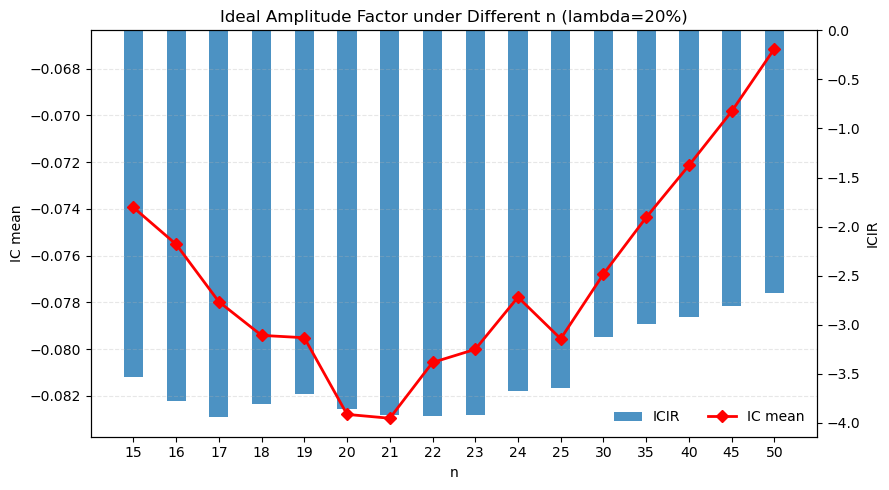

In [61]:
plot_df_n = pd.DataFrame({'n': n_list,'IC均值': [results_v_n[n]['ic_summary']['IC均值'] for n in n_list],
                          'ICIR': [results_v_n[n]['ic_summary']['ICIR'] for n in n_list]})

x = np.arange(len(plot_df_n))

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax2.bar(x, plot_df_n['ICIR'], width=0.45, alpha=0.8, label='ICIR')
ax2.set_ylabel('ICIR')

ax1.plot(x, plot_df_n['IC均值'], marker='D', color = "red", linewidth=2, label='IC mean')
ax1.set_ylabel('IC mean')
ax1.set_xlabel('n')

ax1.set_xticks(x)
ax1.set_xticklabels(plot_df_n['n'].astype(str))

ax1.grid(axis='y', linestyle='--', alpha=0.3)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h2 + h1, l2 + l1, loc='lower right', ncol=2, frameon=False)

# make line axis stay above bar axis
ax1.set_zorder(2)
ax2.set_zorder(1)
ax1.patch.set_visible(False)

ax1.set_title('Ideal Amplitude Factor under Different n (lambda=20%)')

plt.tight_layout()
plt.show()

**不同样本空间：沪深300、中证500、中证1000。**

In [ ]:
# 初始化pro接口
pro = ts.pro_api()

# 不同样本空间
sample_dict = {'HS300': '000300.SH','ZZ500': '000905.SH','ZZ1000': '000852.SH'}

results_sample = {}
merged_sample_dict = {}

In [ ]:
for sample_name, sample_code in tqdm(sample_dict.items(), desc="计算不同样本空间下理想振幅因子表现"):
    
    # 获取回测区间的样本空间
    universe_df = get_history_sample_space_df(pro=pro,start_date='20100430',end_date='20200430',pool_type=sample_code,include_bj=False,
                                              min_list_days=60,freq='M',sleep_interval=0.1)

    # 获取股票池的历史日行情数据
    price_df = get_daily_price_for_universe(pro=pro,universe_df=universe_df,start_date='20100301',end_date='20200430',
                                            fields='ts_code,trade_date,open,high,low,close,pre_close,vol,amount')

    # 整理df
    price_df['trade_date'] = pd.to_datetime(price_df['trade_date'])
    panel_df_sample = price_df.sort_values(['ts_code', 'trade_date']).reset_index(drop=True)

    # 月收益
    df_monthly_base = panel_df_sample.copy()
    df_monthly_base['trade_date'] = pd.to_datetime(df_monthly_base['trade_date'])
    df_monthly_base = df_monthly_base.sort_values(['ts_code', 'trade_date']).copy()

    # 月份标签
    df_monthly_base['year_month'] = df_monthly_base['trade_date'].dt.to_period('M')

    # 每月第一个/最后一个交易日
    df_monthly_first = df_monthly_base.groupby(['ts_code', 'year_month']).first().reset_index()
    df_monthly_last = df_monthly_base.groupby(['ts_code', 'year_month']).last().reset_index()

    # 月收益：月初收盘买入，月末收盘卖出
    df_monthly_return = pd.merge(df_monthly_first[['ts_code', 'year_month', 'close']],df_monthly_last[['ts_code', 'year_month', 'close']],
                                 on=['ts_code', 'year_month'], suffixes=('_start', '_end'))

    df_monthly_return['monthly_return'] = (df_monthly_return['close_end'] / df_monthly_return['close_start'] - 1)

    # 因子计算时统一字段名
    df_for_factor = df_monthly_base.rename(columns={'ts_code': 'ticker', 'trade_date': 'date'}).copy()

    # 日频振幅因子
    df_factor_raw = calculate_amplitude_factors(daily_data=df_for_factor,N=20,lambda_ratio=0.2,ticker_col='ticker',date_col='date'
                                               ).rename(columns={'ticker': 'ts_code', 'date': 'trade_date'})

    # 取每个月最后一个交易日的因子值
    df_factor_raw['year_month'] = df_factor_raw['trade_date'].dt.to_period('M')
    df_factor_monthly = (df_factor_raw.sort_values(['ts_code', 'trade_date']).groupby(['ts_code', 'year_month']).tail(1).reset_index(drop=True))

    # 上个月末信号 -> 下个月收益
    df_factor_monthly['signal_month'] = df_factor_monthly['year_month'] + 1

    temp_df = pd.merge(
        df_monthly_return[['ts_code', 'year_month', 'monthly_return']],
        df_factor_monthly[['ts_code', 'signal_month', 'V_high', 'V_low']],
        left_on=['ts_code', 'year_month'],right_on=['ts_code', 'signal_month'],how='inner')

    temp_df['V'] = temp_df['V_high'] - temp_df['V_low']

    merged_sample_dict[sample_name] = temp_df.copy()

    res_v = run_factor_backtest(panel_df=temp_df,factor_col='V', ret_col='monthly_return', date_col='year_month',
                                freq='M',q=5,fee_rate=0.003,factor_order='ascending')

    results_sample[sample_name] = res_v

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for sample_name in sample_space_dict.keys():
    ls_ret_sample = sample_result_store[sample_name]['group_ret']['Long_Short']
    nav_sample = sample_result_store[sample_name]['long_short_nav'].copy()
    metric_sample = get_metrics(ls_ret_sample, freq='M')
    ann_ret_sample = metric_sample['年化收益率']

    x = nav_sample.index.to_timestamp() if hasattr(nav_sample.index, 'to_timestamp') else nav_sample.index
    ax.plot(x, nav_sample.values, label=f'{sample_name} (AnnRet: {ann_ret_sample})')

ax.set_title('Ideal Amplitude long-short NAV under different sample spaces')
ax.set_ylabel('NAV')
ax.legend(loc='upper left', fontsize='small')
ax.grid(alpha=0.3)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()